# **SISTEMAS DE  VISION 317**
# **PRÁCTICA #6: Detección de ojos y caras.**
**Jose Antonio Martinez Calan 2127803**

IMPORTAR LIBRERÍAS

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import os

DESCARGAR CLASIFICADORES HAAR CASCADE

In [7]:
print(" CLASIFICADORES HAAR CASCADE ")
# URLs de los clasificadores pre-entrenados
classifiers = {
    'frontalface': 'https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_frontalface_default.xml',
    'eye': 'https://raw.githubusercontent.com/opencv/opencv/master/data/haarcascades/haarcascade_eye.xml'
}
# Descargar clasificadores
for name, url in classifiers.items():
    filename = f"haarcascade_{name}.xml"
    if not os.path.exists(filename):
        try:
            urllib.request.urlretrieve(url, filename)
            print(f" {filename} descargado")
        except:
            print(f" Error al descargar {filename}")
    else:
        print(f" {filename} ya existe")

 CLASIFICADORES HAAR CASCADE 
 haarcascade_frontalface.xml ya existe
 haarcascade_eye.xml ya existe


FUNCIÓN PARA MOSTRAR IMÁGENES

In [8]:
def mostrar_imagen(titulo, imagen, tamaño=4):
    """
    Función personalizada para mostrar imágenes
    """
    if imagen is None:
        print(f"❌ Error: La imagen para '{titulo}' es None")
        return
    plt.figure(figsize=(tamaño, tamaño))
    if len(imagen.shape) == 3:
        # Convertir BGR a RGB para mostrar correctamente los colores
        imagen_mostrar = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
        plt.imshow(imagen_mostrar)
    else:
        plt.imshow(imagen, cmap='gray')
    plt.title(titulo, fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

CARGAR CLASIFICADORES

In [9]:
print("\n CARGANDO CLASIFICADORES ")

face_cascade = cv2.CascadeClassifier('haarcascade_frontalface.xml')
eye_cascade = cv2.CascadeClassifier('haarcascade_eye.xml')

# Verificar que los clasificadores se cargaron correctamente
if face_cascade.empty():
    print(" Error: No se pudo cargar el clasificador de caras")
else:
    print(" Clasificador de caras cargado correctamente")

if eye_cascade.empty():
    print(" Error: No se pudo cargar el clasificador de ojos")
else:
    print(" Clasificador de ojos cargado correctamente")


 CARGANDO CLASIFICADORES 
 Clasificador de caras cargado correctamente
 Clasificador de ojos cargado correctamente


ARGAR LA IMAGEN ESPECÍFICA

In [10]:
print("\n=== CARGANDO IMAGEN ===")
image = cv2.imread('Fotografia.jpg')
# Verificar si la imagen se cargó correctamente
if image is None:
    print(" Error: No se pudo cargar 'Fotografia.jpg'")
    print("  Verificando en subdirectorios...")
    # Intentar cargar desde sample_data
    image = cv2.imread('sample_data/Fotografia.jpg')
    if image is None:
        print(" No se encontró 'Fotografia")
        print(" Creando imagen de ejemplo...")
        # Crear imagen sintética con caras
        image = np.ones((500, 700, 3), dtype=np.uint8) * 255  # Fondo blanco
        # Dibujar caras simples (óvalos)
        cv2.ellipse(image, (150, 200), (80, 100), 0, 0, 360, (200, 200, 200), -1)  # Cara 1
        cv2.ellipse(image, (400, 250), (70, 90), 0, 0, 360, (200, 200, 200), -1)   # Cara 2
        # Dibujar ojos en las caras
        cv2.circle(image, (130, 180), 15, (0, 0, 0), -1)  # Ojo izquierdo cara 1
        cv2.circle(image, (170, 180), 15, (0, 0, 0), -1)  # Ojo derecho cara 1
        cv2.circle(image, (380, 230), 12, (0, 0, 0), -1)  # Ojo izquierdo cara 2
        cv2.circle(image, (420, 230), 12, (0, 0, 0), -1)  # Ojo derecho cara 2
        print(" Imagen de ejemplo creada")
    else:
        print(" Imagen cargada desde: sample_data/Fotografia.jpg")
else:
    print(" Imagen 'Fotografia.jpg' cargada exitosamente")
print(f" Dimensiones de la imagen: {image.shape}")


=== CARGANDO IMAGEN ===
 Imagen 'Fotografia.jpg' cargada exitosamente
 Dimensiones de la imagen: (2048, 1542, 3)


MOSTRAR IMAGEN ORIGINAL


 IMAGEN ORIGINAL 


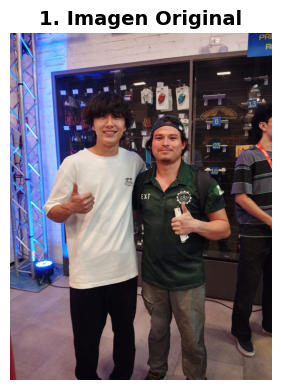

In [12]:
print("\n IMAGEN ORIGINAL ")
mostrar_imagen("1. Imagen Original", image)

CONVERTIR A ESCALA DE GRISES


 PREPROCESAMIENTO 


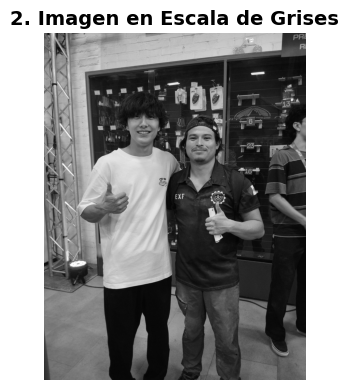

In [13]:
print("\n PREPROCESAMIENTO ")
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
mostrar_imagen("2. Imagen en Escala de Grises", gray)

DETECCIÓN DE CARAS

In [14]:
print("\n DETECTANDO CARAS ")
faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.3,    # Parámetro de escala
    minNeighbors=5,     # Mínimo de vecinos
    minSize=(30, 30)    # Tamaño mínimo de cara
)
print(f" Caras detectadas: {len(faces)}")
# Crear copia para dibujar resultados
image_with_detections = image.copy()


 DETECTANDO CARAS 
 Caras detectadas: 3


DETECCIÓN DE OJOS DENTRO DE CADA CARA

In [15]:
total_ojos = 0
if len(faces) > 0:
    for i, (x, y, w, h) in enumerate(faces):
        print(f"\n  Cara {i+1}: Posición=({x}, {y}), Tamaño=({w}, {h})")
        # Dibujar rectángulo alrededor de la cara (AZUL)
        cv2.rectangle(image_with_detections, (x, y), (x+w, y+h), (255, 0, 0), 3)
        cv2.putText(image_with_detections, f'Cara {i+1}', (x, y-10),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)
        # Región de interés (ROI) para la cara actual
        roi_gray = gray[y:y+h, x:x+w]
        roi_color = image_with_detections[y:y+h, x:x+w]
        # Detectar ojos dentro de la cara
        eyes = eye_cascade.detectMultiScale(
            roi_gray,
            scaleFactor=1.1,
            minNeighbors=3,
            minSize=(20, 20)
        )
        print(f"  Ojos detectados en cara {i+1}: {len(eyes)}")
        total_ojos += len(eyes)
        # Dibujar rectángulos alrededor de los ojos (VERDE)
        for j, (ex, ey, ew, eh) in enumerate(eyes):
            cv2.rectangle(roi_color, (ex, ey), (ex+ew, ey+eh), (0, 255, 0), 2)
            cv2.putText(roi_color, f'Ojo{j+1}', (ex, ey-5),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 0), 1)
else:
    print(" No se detectaron caras en la imagen")
    print(" Intentando con parámetros más sensibles...")
    # Segundo intento con parámetros más sensibles
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=3,
        minSize=(20, 20)
    )
    if len(faces) > 0:
        print(f" Caras detectadas (parámetros ajustados): {len(faces)}")
        for i, (x, y, w, h) in enumerate(faces):
            cv2.rectangle(image_with_detections, (x, y), (x+w, y+h), (255, 0, 0), 3)
            cv2.putText(image_with_detections, f'Cara {i+1}', (x, y-10),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)
            roi_gray = gray[y:y+h, x:x+w]
            eyes = eye_cascade.detectMultiScale(roi_gray, 1.1, 3, minSize=(15, 15))
            print(f"      👀 Ojos detectados en cara {i+1}: {len(eyes)}")
            total_ojos += len(eyes)
            for j, (ex, ey, ew, eh) in enumerate(eyes):
                cv2.rectangle(image_with_detections[y:y+h, x:x+w], (ex, ey), (ex+ew, ey+eh), (0, 255, 0), 2)
    else:
        print(" No se detectaron caras incluso con parámetros ajustados")


  Cara 1: Posición=(466, 407), Tamaño=(239, 239)
  Ojos detectados en cara 1: 0

  Cara 2: Posición=(811, 532), Tamaño=(216, 216)
  Ojos detectados en cara 2: 2

  Cara 3: Posición=(660, 832), Tamaño=(86, 86)
  Ojos detectados en cara 3: 0


MOSTRAR RESULTADOS FINALES


 RESULTADOS 


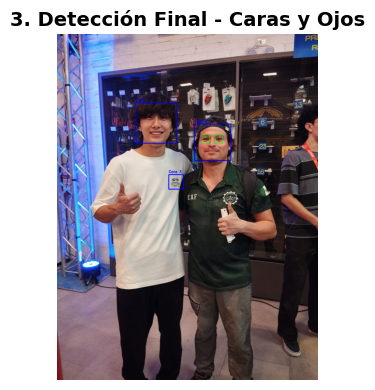

In [16]:

print("\n RESULTADOS ")
mostrar_imagen("3. Detección Final - Caras y Ojos", image_with_detections)